In [10]:
import pandas as pd

In [13]:
df=pd.read_csv('/content/Hotel Reviews Data.csv', encoding='latin1')

In [14]:
df.head()

,Review,date,Location
0,I was very impressed with the resort.\nGreat s...,20-08-2019,Sebastian
1,The rooms were nice the outside needs work als...,20-08-2019,Los Angeles
2,Great location! I have stayed at this hotel on...,20-08-2019,Georgia
3,The hotel was adequate for my stay. The strips...,20-08-2019,NaN
4,"Great location, room was large and spacious. P...",19-08-2019,Palm Harbor


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6448 entries, 0 to 6447
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Review    6393 non-null   object
 1   date      6448 non-null   object
 2   Location  1711 non-null   object
dtypes: object(3)
memory usage: 151.3+ KB


In [16]:
import pandas as pd
import numpy as np
import re
import string
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('vader_lexicon')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [18]:
missing_reviews = df['Review'].isnull().sum()
print(f"Number of missing values in 'Review' column: {missing_reviews}")

Number of missing values in 'Review' column: 55


In [19]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    if not isinstance(text, str):
        return "" # Handle non-string types, especially NaN which is a float
    text = text.lower()
    text = re.sub(r'[^a-zA-Z ]', '', text)
    words = text.split()
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    return " ".join(words)

df["Clean_Review"] = df["Review"].apply(clean_text)

print(df["Clean_Review"].head())

0    impressed resortgreat staff main resort pool b...
1    room nice outside need work also free breakfas...
2    great location stayed hotel last three trip ne...
3    hotel adequate stay strip bathtub useless fell...
4    great location room large spacious parking eas...
Name: Clean_Review, dtype: object


In [20]:
pip install textblob

In [21]:
from textblob import TextBlob

def get_sentiment(text):
    score = TextBlob(text).sentiment.polarity

    if score > 0:
        return "Positive"
    elif score < 0:
        return "Negative"
    else:
        return "Neutral"

df["Sentiment"] = df["Clean_Review"].apply(get_sentiment)

print(df["Sentiment"].value_counts())


Sentiment
Positive    4465
Negative    1875
Neutral      108
Name: count, dtype: int64


In [23]:
issues = [
    "room",
    "clean",
    "staff",
    "food",
    "wifi",
    "service",
    "bathroom",
    "location"
]

for issue in issues:
    count = df["Clean_Review"].str.contains(issue).sum()
    print(issue, ":", count)

room : 3031
clean : 1514
staff : 1668
food : 281
wifi : 83
service : 647
bathroom : 444
location : 1321


In [24]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(max_features=20)

X = vectorizer.fit_transform(df["Clean_Review"])

words = vectorizer.get_feature_names_out()

counts = X.toarray().sum(axis=0)

result = pd.DataFrame({
    "Word": words,
    "Frequency": counts
})

print(result.sort_values("Frequency", ascending=False))

        Word  Frequency
7       less       5358
9   moreread       5311
14      room       4436
6      hotel       2983
16     staff       1713
5      great       1562
8   location       1302
2      clean       1265
17      stay       1249
10      nice       1174
13      read        954
4       good        924
18      time        900
0        bed        812
19     would        749
11     night        736
3   friendly        734
12      pool        667
15   service        658
1      check        619


In [25]:
print(df["Sentiment"].value_counts())

Sentiment
Positive    4465
Negative    1875
Neutral      108
Name: count, dtype: int64


In [27]:
sentiment_distribution = df["Sentiment"].value_counts(normalize=True) * 100
print("Sentiment Distribution (Percentage):")
print(sentiment_distribution)

Sentiment Distribution (Percentage):
Sentiment
Positive    69.246278
Negative    29.078784
Neutral      1.674938
Name: proportion, dtype: float64


In [28]:
positive = (df["Sentiment"] == "Positive").sum()
negative = (df["Sentiment"] == "Negative").sum()
neutral = (df["Sentiment"] == "Neutral").sum()

total = len(df)

print("Positive %:", positive * 100 / total)
print("Negative %:", negative * 100 / total)
print("Neutral %:", neutral * 100 / total)

Positive %: 69.24627791563276
Negative %: 29.0787841191067
Neutral %: 1.6749379652605458


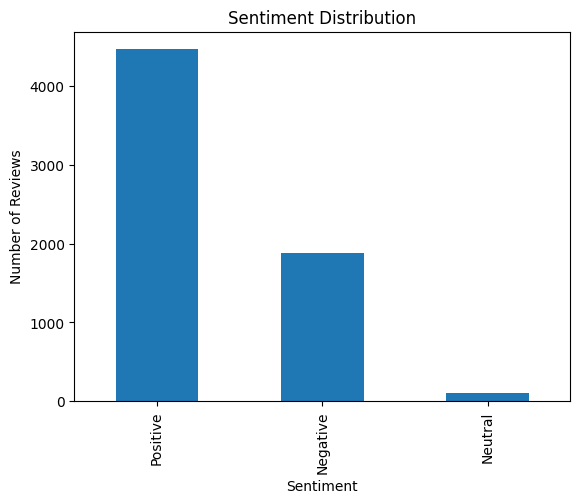

In [29]:
import matplotlib.pyplot as plt

df["Sentiment"].value_counts().plot(kind='bar')

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()


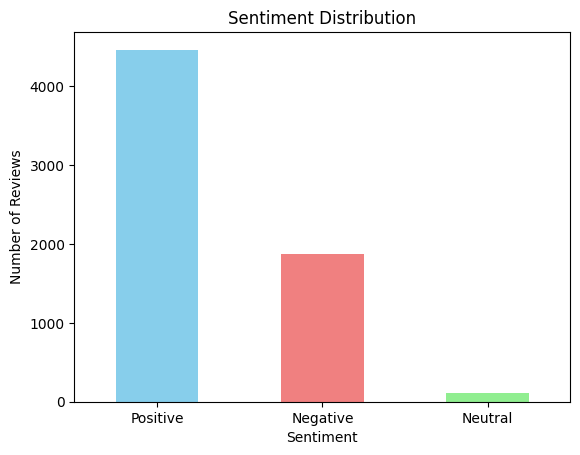

In [31]:
df["Sentiment"].value_counts().plot(kind='bar', color=['skyblue', 'lightcoral', 'lightgreen'])

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.show()

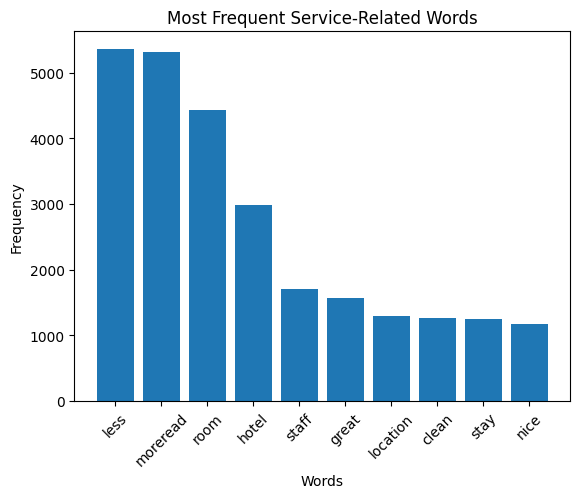

In [32]:
top10 = result.sort_values("Frequency", ascending=False).head(10)

plt.bar(top10["Word"], top10["Frequency"])

plt.xticks(rotation=45)
plt.title("Most Frequent Service-Related Words")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.show()